# Airbnb Barcelona - Data Cleaning and Feature Engineering 

This notebook deals primarily with the data given in listings.csv.gz and shows our general approach on preprocessing it, but it is important to note, that we load a csv file generated in another notebook. The result will be one test and one train set that can be used for training. In reality we will generate multiple train and test sets we train on, that contain different samples and slightly different feature selections (see src/data/loading.py for more information).

## Imports & Loading

In [1]:
import sys
import os
import pandas as pd
import numpy as np

sys.path.append(os.path.abspath('..'))
import src.data.preprocessing as dpp
import src.utility.util as utl


In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
# Load DataFrames
listings_df = pd.read_csv('../data/listings.csv.gz', low_memory=False)
sentiments_df = pd.read_csv('../data/sentiment_features_unweighted.csv', low_memory=False)

# Print shapes
print(f'listing.csv size: {listings_df.shape}')
print(f'sentiments.csv size: {sentiments_df.shape}')

listing.csv size: (19410, 79)
sentiments.csv size: (14421, 13)


We merge the sentiment scores with our listings data.

In [4]:
df = pd.merge(listings_df, sentiments_df, left_on='id', right_on='listing_id', how='outer')

In [5]:
# Print shape
print(f'Airbnb df: {df.shape}')

Airbnb df: (19410, 92)


## Initial overview

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19410 entries, 0 to 19409
Data columns (total 92 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            19410 non-null  int64  
 1   listing_url                                   19410 non-null  object 
 2   scrape_id                                     19410 non-null  int64  
 3   last_scraped                                  19410 non-null  object 
 4   source                                        19410 non-null  object 
 5   name                                          19410 non-null  object 
 6   description                                   18673 non-null  object 
 7   neighborhood_overview                         8986 non-null   object 
 8   picture_url                                   19410 non-null  object 
 9   host_id                                       19410 non-null 

Descriptions of the features are found here: https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4/edit?gid=1322284596#gid=1322284596

We observe many missing values for a lot of the features and there are many features that shouldn't affect the price:

* **id**: Shouldn't contain relevant information that affects the price
* **listing_url**: Shouldn't contain relevant information that affects the price
* **scrape_id**: Shouldn't contain relevant information that affects the price
* **last_scraped**: Shouldn't contain relevant information that affects the price
* **source**: Shouldn't contain relevant information that affects the price
* **name**: Shouldn't contain relevant information that affects the price
* **neighborhood_overview**: Insufficient amount of data for training (only 8986 non-null out of 19410)
* **host_id**: Shouldn't contain relevant information that affects the price
* **host_url**: Shouldn't contain relevant information that affects the price
* **host_name**: Shouldn't contain relevant information that affects the price
* **host_location**: Shouldn't contain relevant information that affects the price
* **host_about**: Insufficient amount of data for training
* **host_thumbnail_url**: Shouldn't contain relevant information that affects the price
* **host_neighbourhood**: Shouldn't contain relevant information that affects the price
* **neighbourhood**: Insufficient amount of data for training
* **bathroom**: Has missing values and there is a more useful feature 'bathrooms_text' that contains additional information
* **minimum_minimum_nights**: Shouldn't contain relevant information that affects the price
* **maximum_minimum_nights**: Shouldn't contain relevant information that affects the price
* **minimum_maximum_nights**: Shouldn't contain relevant information that affects the price
* **maximum_maximum_nights**: Shouldn't contain relevant information that affects the price
* **minimum_nights_avg_ntm**: Shouldn't contain relevant information that affects the price
* **maximum_nights_avg_ntm**: Shouldn't contain relevant information that affects the price
* **calender_updated**: Insufficient amount of data for training (missing value for all samples)
* **calendar_last_scraped**: Shouldn't contain relevant information that affects the price
* **first_review**: Shouldn't contain relevant information that affects the price
* **last_review**: Shouldn't contain relevant information that affects the price
* **license**: Many missing values.

### Price
The price feature is our target. We can observe that many samples have a missing value for a price, so we have to drop these samples. We will also see that each price is currently in the same string format. We determine the format and convert it to floating point numbers.

In [7]:
# Show how many samples contain a price
print(df['price'].info())

<class 'pandas.core.series.Series'>
RangeIndex: 19410 entries, 0 to 19409
Series name: price
Non-Null Count  Dtype 
--------------  ----- 
15276 non-null  object
dtypes: object(1)
memory usage: 151.8+ KB
None


In [8]:
# Inspect format of prices
print(df['price'].value_counts())

price
$60.00        240
$100.00       173
$80.00        169
$70.00        169
$50.00        165
$65.00        148
$90.00        144
$95.00        141
$75.00        134
$40.00        133
$45.00        131
$55.00        124
$30.00        123
$72.00        117
$35.00        116
$58.00        102
$62.00        102
$120.00       102
$110.00       100
$150.00       100
$69.00         93
$68.00         91
$130.00        89
$250.00        87
$85.00         87
$91.00         86
$200.00        86
$89.00         86
$64.00         86
$48.00         83
$190.00        83
$36.00         81
$180.00        78
$135.00        75
$63.00         75
$67.00         74
$140.00        72
$25.00         72
$81.00         71
$28.00         71
$175.00        71
$79.00         69
$94.00         69
$52.00         69
$88.00         68
$128.00        68
$83.00         68
$66.00         67
$32.00         66
$51.00         66
$39.00         65
$38.00         65
$59.00         64
$47.00         63
$144.00        63
$54.

In [9]:
# Drop samples having a missing price and convert prices to float
df = dpp.price(df)

In [10]:
# Print shape
print(df.shape)

(15276, 92)


We take a look at its distribution. We observe that the distribution is heavily skewed. We will log transform the price later 

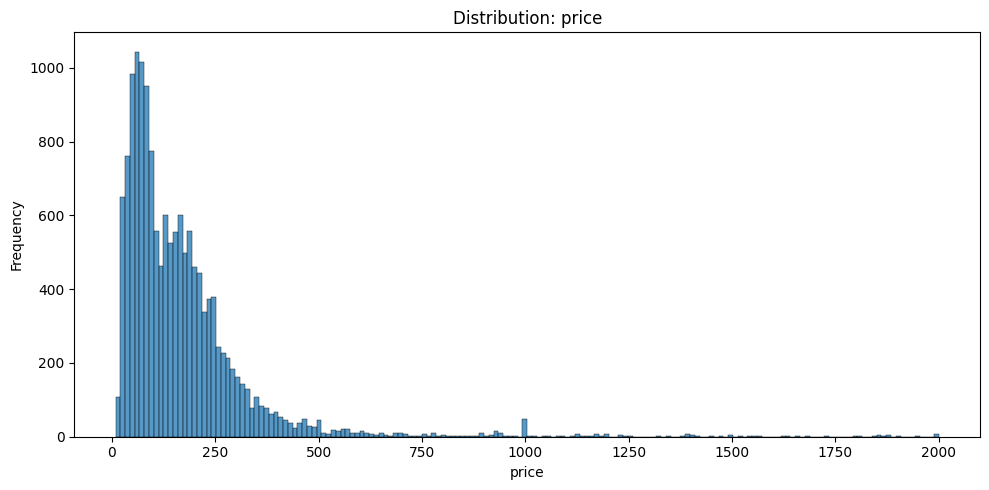

In [11]:
utl.plot_distributions(df[['price']].loc[df['price'] <= 2000], ['price'])

### Feature selection
We throw out features with too many missing values and that are useless for predicting the price (see features above). We keep the features from our sentiments DataFrame.

In [12]:
feature_selection_listings = ['amenities', 'host_since', 'host_response_time', 'host_response_rate', 
    'host_acceptance_rate','host_is_superhost', 'host_listings_count', 'host_has_profile_pic', 
    'host_identity_verified', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed',
    'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms_text',
    'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights', 'availability_30', 'availability_365', 
    'number_of_reviews', 'number_of_reviews_ltm', 'review_scores_rating', 'review_scores_accuracy', 
    'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 
    'review_scores_location', 'review_scores_value', 'instant_bookable', 'reviews_per_month',
]

# List of review_scores
review_scores_features = [
    'review_scores_accuracy', 'review_scores_checkin', 'review_scores_cleanliness',
    'review_scores_rating', 'review_scores_value', 'review_scores_location', 
    'reviews_per_month', 'review_scores_communication'
]

# List of sentiment features (of sentiments_df generated from pretrained model)
sentiment_features = [
    'median_sentiment', 'min_sentiment', 'max_sentiment',
    'std_sentiment', 'sentiment_range', 'pct_negative', 'total_reviews_scored',
    'days_since_last_review', 'review_velocity', 'recent_mean_sentiment',
    'sentiment_trend', 'mean_sentiment'
]

We need the review_scores and sentiment features separately later. Therefore we put them here in separate lists.

In [13]:
df = df[feature_selection_listings + sentiment_features]

In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 15276 entries, 0 to 19409
Data columns (total 47 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   amenities                     15276 non-null  object 
 1   host_since                    15273 non-null  object 
 2   host_response_time            14384 non-null  object 
 3   host_response_rate            14384 non-null  object 
 4   host_acceptance_rate          14624 non-null  object 
 5   host_is_superhost             14946 non-null  object 
 6   host_listings_count           15273 non-null  float64
 7   host_has_profile_pic          15273 non-null  object 
 8   host_identity_verified        15273 non-null  object 
 9   neighbourhood_cleansed        15276 non-null  object 
 10  neighbourhood_group_cleansed  15276 non-null  object 
 11  latitude                      15276 non-null  float64
 12  longitude                     15276 non-null  float64
 13  proper

## Splitting
Before we clean our data we split the DataFrame into a train set and a test set.

In [15]:
# Define the target
target_feature = 'price'

X = df.drop(target_feature, axis=1)
y = df[target_feature]

# Split the data
X_train, X_test, y_train, y_test = dpp.split(df, target_feature, test_size=0.2, random_state=42)

In [16]:
# Shapes
print(f'X_train.shape = {X_train.shape}')
print(f'X_test.shape = {X_test.shape}')
print(f'y_train.shape = {y_train.shape}')
print(f'y_test.shape = {y_test.shape}')


X_train.shape = (12220, 46)
X_test.shape = (3056, 46)
y_train.shape = (12220,)
y_test.shape = (3056,)


## Dropping
We will see that almost 23 percent of samples of the train set are missing **all** the 'review_scores_*' and 'sentiment_features' features. We consider multiple ways of dealing with the missing review_scores: 
1. drop the samples where any review_scores / sentiment feature is missing
2. add a flag whether a sample has all review_scores or not and fill missing values with 0.
3. drop the columns and train without review_scores / sentiment features

We will create train and test sets with each approach. In this notebook we only take a look at approach 1.

In [17]:
utl.show_missing_values_info(X_train)

Total number of samples: 12220
----------------------------------------
MISSING VALUE w.r.t. FEATURE:
                             Number of NaN  Percentage (%)
review_scores_accuracy                2795           22.87
review_scores_checkin                 2795           22.87
review_scores_cleanliness             2795           22.87
review_scores_rating                  2794           22.86
total_reviews_scored                  2794           22.86
pct_negative                          2794           22.86
sentiment_range                       2794           22.86
std_sentiment                         2794           22.86
max_sentiment                         2794           22.86
min_sentiment                         2794           22.86
median_sentiment                      2794           22.86
reviews_per_month                     2794           22.86
review_scores_value                   2794           22.86
review_scores_location                2794           22.86
review_scores

In [18]:
# Count how many samples miss all review_scores and sentiment features
cond = X_train[review_scores_features + sentiment_features].isna().sum(axis=1) == len(review_scores_features + sentiment_features)
print(len(X_train[cond]))

2794


Create the flag indicating whether a sample has all review_scores / sentiment features and fill missing values with 0.

In [19]:
feature_name = 'review_scores'
X_train = dpp.create_has_all_features_flag(X_train, review_scores_features + sentiment_features, feature_name)
X_test = dpp.create_has_all_features_flag(X_test, review_scores_features + sentiment_features, feature_name)

There are still some features left that have up to 6 % missing values. Instead of dropping them, we will fill them (mostly with their medians or modes), since the amount of missing numbers is should be of insignificant impact.

In [20]:
utl.show_missing_values_info(X_train)

print('\nShapes:')
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

Total number of samples: 12220
----------------------------------------
MISSING VALUE w.r.t. FEATURE:
                        Number of NaN  Percentage (%)
host_response_time                725            5.93
host_response_rate                725            5.93
host_acceptance_rate              518            4.24
host_is_superhost                 261            2.14
beds                               57            0.47
bedrooms                           19            0.16
bathrooms_text                      8            0.07
host_since                          3            0.02
host_listings_count                 3            0.02
host_has_profile_pic                3            0.02
host_identity_verified              3            0.02
----------------------------------------
MISSING VALUE w.r.t. SAMPLE:
- There are 408 rows (samples) with 1 missing features
- There are 292 rows (samples) with 2 missing features
- There are 424 rows (samples) with 3 missing features
- There are 10 

## Datatype conversion, filling, encoding & log-transforms
In this step we convert everything into numerical data and fill the few missing values. We also apply log transformations on features that have skewed distributions.

Overall the given data is already quite clean. For example, the format of the 'host_since' feature is the same for each sample. This holds for all the other features. Hence we will at times only inspect the format on the train set to provide a clearer overview.

To process the following features, we will make use of a collection of functions we defined in **src/data/preprocessing.py**.

### host_since

The host_since feature is the date on which a host became a host for the first time. We are going to convert it into the number of days the host has been a host until the date of the scrape.

We can assume that all dates are in format "yyyy-mm-dd" looking at the data.

In [21]:
# Inspect format of host_since
print(X_train['host_since'].value_counts())

host_since
2020-05-15    347
2011-11-27    257
2015-04-27    198
2018-10-19    185
2020-07-23    184
2012-12-21    166
2014-09-24    166
2019-05-30    138
2022-03-01    120
2015-06-24    101
2010-11-26     97
2017-11-09     91
2023-03-06     91
2013-10-13     78
2025-07-11     74
2022-03-14     72
2023-06-08     69
2012-09-13     66
2015-05-13     60
2019-03-20     55
2021-12-30     53
2011-12-14     53
2011-02-17     52
2013-08-13     50
2011-11-10     48
2023-12-11     46
2017-05-14     45
2025-01-14     45
2017-05-05     41
2024-11-11     38
2016-04-08     37
2016-02-16     36
2015-06-16     36
2015-10-22     36
2011-11-22     35
2013-12-10     35
2012-02-13     35
2020-02-05     34
2024-05-26     34
2015-07-28     33
2013-03-25     33
2019-06-25     33
2011-10-19     31
2016-03-28     31
2020-10-05     31
2013-12-02     30
2022-04-14     29
2011-04-03     29
2015-09-07     28
2025-07-01     28
2012-05-08     27
2012-11-27     27
2013-10-17     27
2015-01-22     27
2019-11-11     26

We extract the date on which the date was scraped.

In [22]:
# Check if all listings were scraped on the same date
print(f"Samples scraped on the same date: {listings_df['last_scraped'].duplicated(keep=False).all()}")

Samples scraped on the same date: True


Since all samples were scraped on the same day, we can simply extract the date from one sample.

In [23]:
# Extract the date of the scrape
date_of_scrape = pd.to_datetime(listings_df["last_scraped"][0])

Now we convert the date and fill the few missing values with the median of the train set.

In [24]:
# Convert date to the number of days and fill missing values with the median
X_train, X_test = dpp.host_since(X_train, X_test, date_of_scrape)

Distribution:

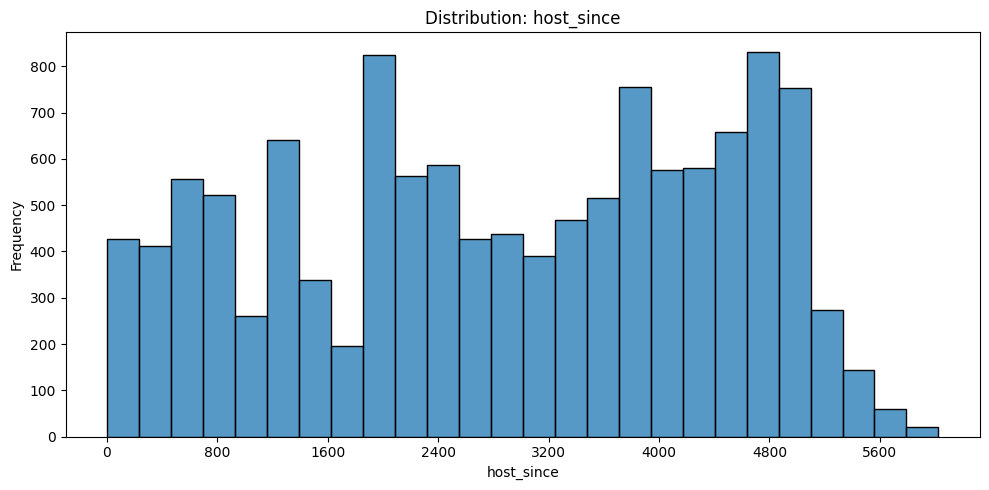

In [25]:
utl.plot_distributions(X_train, columns=['host_since'])

### host_response_time

The host_response_time indicates how fast a host responds to requests. There are four types of host response times. We give them a grading (see **src/data/preprocessing.py**) and encode the feature ordinally. We grade each type, because 'within an hour' is significantly better than 'a few days or more', but not much better 'within a few hours'.

In [26]:
print(X_train['host_response_time'].value_counts(), '\n')
print(X_test['host_response_time'].value_counts())

host_response_time
within an hour        8260
within a few hours    1994
within a day           918
a few days or more     323
Name: count, dtype: int64 

host_response_time
within an hour        2058
within a few hours     524
within a day           222
a few days or more      85
Name: count, dtype: int64


In [27]:
# Fill missing values with the train sets mode and then ordinal encode 'host_response_time'
X_train, X_test = dpp.host_response_time_ordinal_encoding(X_train, X_test)

In [28]:
print(X_train['host_response_time'].value_counts(), '\n')
print(X_test['host_response_time'].value_counts())

host_response_time
1.0     8985
5.0     1994
12.0     918
36.0     323
Name: count, dtype: int64 

host_response_time
1.0     2225
5.0      524
12.0     222
36.0      85
Name: count, dtype: int64


Distribution:

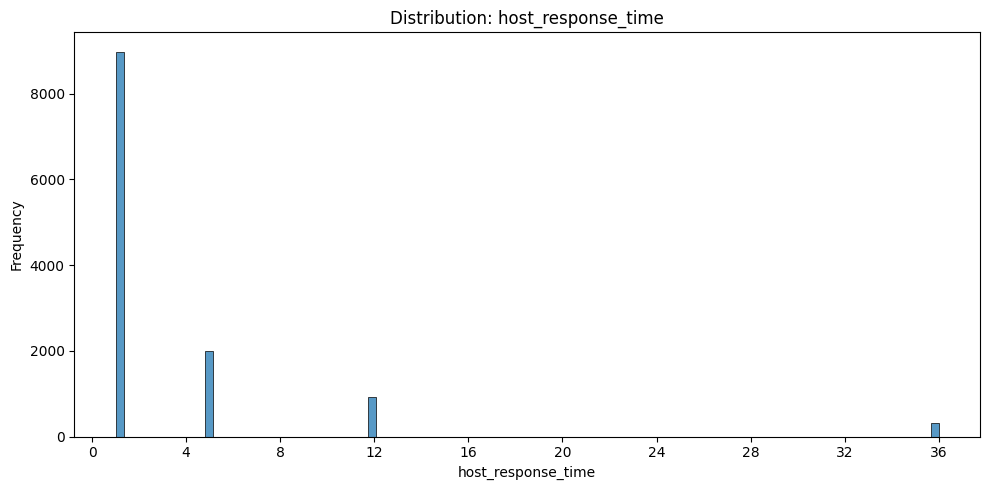

In [29]:
utl.plot_distributions(X_train, columns=['host_response_time'])

### host_response_rate & host_acceptance_rate

The host_response_rate is the rate of to how many requests a host responds. The host_acceptance_rate is the rate at which a host accepts booking requests. They are in a string format and we simply convert it to floating point number.

In [30]:
# Inspect the format of the host_response_rates / acceptance
print(f"X_train, response rate: {X_train['host_response_rate'].unique()}\n")
print(f"X_train, acceptance rate: {X_train['host_acceptance_rate'].unique()}\n")

X_train, response rate: ['100%' '22%' '92%' '97%' '82%' '96%' '99%' '98%' '94%' nan '10%' '87%'
 '91%' '95%' '90%' '85%' '67%' '76%' '93%' '50%' '59%' '83%' '88%' '40%'
 '60%' '38%' '0%' '75%' '89%' '80%' '70%' '20%' '79%' '86%' '84%' '81%'
 '33%' '14%' '53%' '74%' '72%' '78%' '58%' '41%' '17%' '73%' '25%' '56%'
 '71%' '64%' '63%' '69%' '52%' '57%' '43%' '32%' '15%' '46%' '8%' '19%'
 '29%' '77%' '11%' '62%' '48%' '61%' '16%']

X_train, acceptance rate: ['99%' '73%' '100%' '5%' '86%' '82%' '98%' '79%' '96%' '75%' '93%' nan
 '62%' '6%' '97%' '76%' '41%' '87%' '95%' '0%' '89%' '94%' '36%' '57%'
 '71%' '70%' '85%' '51%' '67%' '60%' '92%' '45%' '28%' '31%' '80%' '74%'
 '72%' '23%' '15%' '68%' '64%' '69%' '90%' '50%' '49%' '46%' '12%' '61%'
 '47%' '88%' '54%' '11%' '40%' '91%' '44%' '25%' '56%' '81%' '14%' '55%'
 '78%' '20%' '17%' '84%' '83%' '38%' '32%' '33%' '65%' '63%' '66%' '30%'
 '58%' '77%' '59%' '37%' '26%' '52%' '18%' '43%' '53%' '3%' '42%' '48%'
 '29%' '10%' '13%' '4%' '22%' '2%' '3

In [31]:
# Remove '%' and convert to float and fill missing values with their medians
X_train, X_test = dpp.host_response_rate(X_train, X_test)
X_train, X_test = dpp.host_acceptance_rate(X_train, X_test)

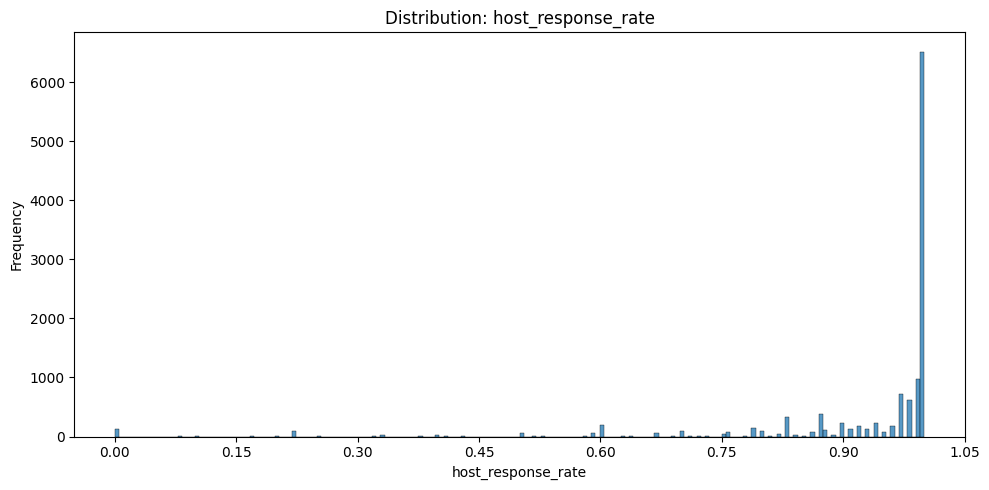

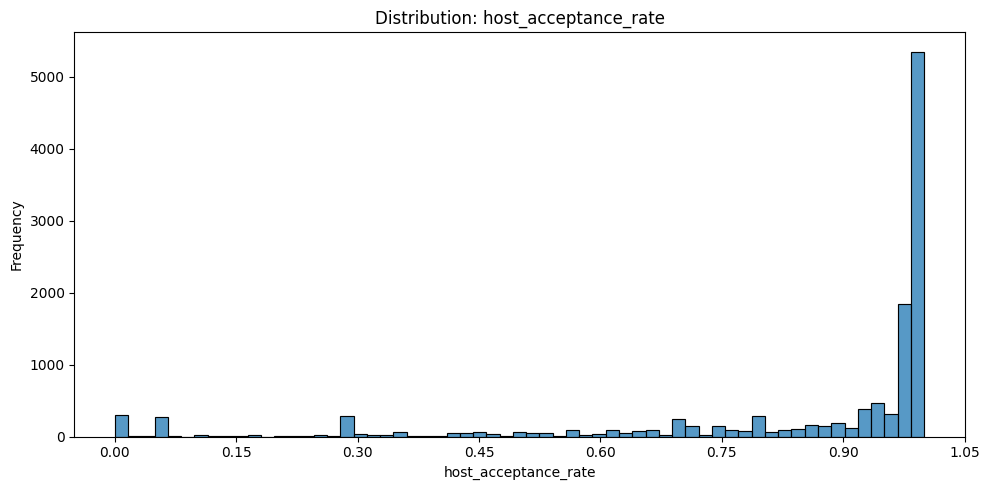

In [32]:
utl.plot_distributions(X_train, columns=['host_response_rate', 'host_acceptance_rate'])

### host_is_superhost, host_has_profile_pic, host_identity_verified & instant_bookable

These are binary features that are either "t" or "f". We simply convert them to 0 and 1 and fill missing values with the most frequent value (mode).

In [33]:
# Create list of the features
binary_host_features = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable']

# Check the formats
print(X_train[binary_host_features].apply(pd.Series.unique))

host_is_superhost         [t, f, nan]
host_has_profile_pic      [t, f, nan]
host_identity_verified    [t, f, nan]
instant_bookable               [f, t]
dtype: object


In [34]:
# Map features to numerical values and fill missing values with their modes
X_train, X_test = dpp.host_is_superhost(X_train, X_test)
X_train, X_test = dpp.host_has_profile_pic(X_train, X_test)
X_train, X_test = dpp.host_identity_verified(X_train, X_test)
X_train, X_test = dpp.instant_bookable(X_train, X_test)

### host_listings_count

host_listings_count is the amount of listings a host created and is already numerical. We fill missing values with the median.

In [35]:
# Fill with its median
X_train, X_test = dpp.median_fill(X_train, X_test, ['host_listings_count'])

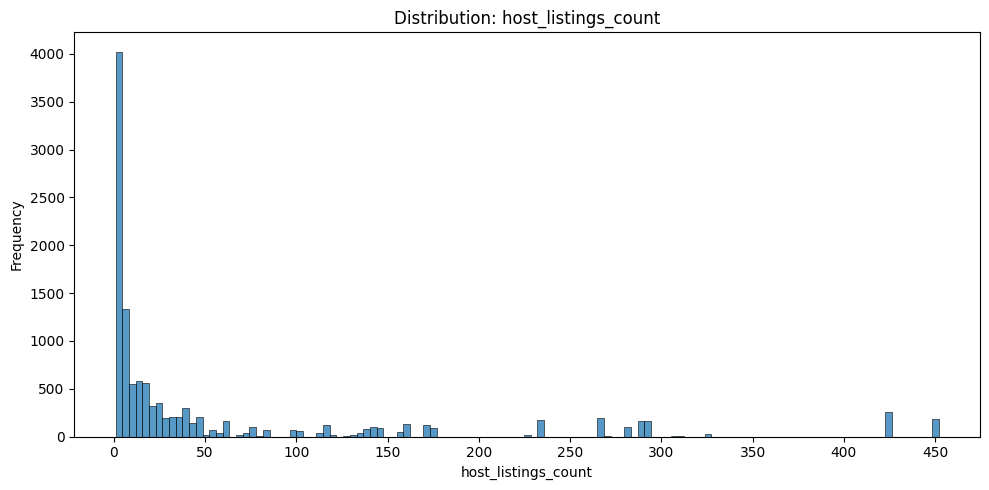

In [36]:
utl.plot_distributions(X_train[['host_listings_count']].loc[X_train['host_listings_count'] < 500], ['host_listings_count'])

### beds & bedrooms

beds is the number of beds and bedrooms the number of bedrooms a listing contains. We fill missing values with the median.

In [37]:
# Fill missing values with their medians
X_train, X_test = dpp.median_fill(X_train, X_test, ['beds', 'bedrooms'])

### room_type
The room_type consists of four types and is in a string format. We use one-hot-encoding to indicate numerically which type a sample is of.

In [38]:
# Inspect format 
print(X_train['room_type'].unique())


['Entire home/apt' 'Private room' 'Shared room' 'Hotel room']


In [39]:
# Fill missing values with the mode first, then one hot encode the types and drop the original feature room_type
X_train, X_test = dpp.room_type(X_train, X_test)

In [40]:
print(X_train[['room_type_entire_home_apt', 'room_type_hotel_room', 'room_type_private_room', 'room_type_shared_room']].info())

<class 'pandas.core.frame.DataFrame'>
Index: 12220 entries, 7291 to 10209
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   room_type_entire_home_apt  12220 non-null  float64
 1   room_type_hotel_room       12220 non-null  float64
 2   room_type_private_room     12220 non-null  float64
 3   room_type_shared_room      12220 non-null  float64
dtypes: float64(4)
memory usage: 477.3 KB
None


### bathrooms_text:
bathrooms_text contains a brief description of the listings bathrooms and how many bathrooms the listing has. We extract the number and encode whether the bathroom is shared or private.

First we figure out the set of all bathroom texts:

In [41]:
# Inspect format and values
bathroom_descriptions = (
    X_train['bathrooms_text']
    .dropna()
    .str.lower().replace(r'[-0-9. ]+', '', regex=True)      # Remove numbers to extract the text
    .unique()
)

print(bathroom_descriptions)

['bath' 'sharedhalfbath' 'sharedbath' 'sharedbaths' 'baths' 'privatebath'
 'halfbath' 'privatehalfbath']


We create new feature for the number of baths and a feature indicating whether the bath is shared or not. (A bath is assumed to be private if it doesn't contain the word 'shared')

In [42]:
# Extract the number of bathrooms (half-bath = 0.5) and create a new feature 'shared_bath' indicating a shared or private bath
# Fill number of bathroom with its median and shared_bath with its mode
# Drop the original feature
X_train, X_test = dpp.bathrooms_text(X_train, X_test)

### property_type

There are many different property types. We are looking to provide a grading based on the mean price of each property_type. For that we use a target encoder. It also diminishes the impact of outliers by encoding rare types with a value closer to the global mean of prices. 

In [43]:
print(X_train['property_type'].str.lower().unique())

print('\nTrain property types == Test property types:', set(X_train['property_type'].str.lower().unique()) == set(X_test['property_type'].str.lower().unique()))

['entire loft' 'private room in rental unit' 'entire rental unit'
 'entire serviced apartment' 'entire home' 'private room in condo'
 'private room in bed and breakfast' 'private room in hostel'
 'room in boutique hotel' 'room in hotel' 'shared room in hostel'
 'entire condo' 'room in serviced apartment' 'room in aparthotel'
 'shared room in boutique hotel' 'private room in loft'
 'private room in home' 'private room in casa particular'
 'entire guest suite' 'private room in guesthouse'
 'shared room in rental unit' 'shared room in hotel'
 'private room in boat' 'boat' 'entire hostel' 'private room in dome'
 'entire villa' 'dome' 'room in hostel' 'camper/rv'
 'private room in townhouse' 'entire townhouse' 'entire vacation home'
 'private room' 'tiny home' 'private room in serviced apartment'
 'entire guesthouse' 'private room in tiny home' 'barn'
 'private room in guest suite' 'shared room in home' 'casa particular'
 'shared room in guesthouse' 'private room in chalet' 'entire place'
 

In [44]:
# Fill missing values with its mode and apply target encoding
X_train, X_test = dpp.property_type(X_train, X_test, y_train)

### amenities
We one hot encode the amenities using a multi label binarizer (mlb), because each sample contains multiple amenities in a list. The mlb looks to encode each element of a amenity list whereas the simple one hot encoder would see the whole list as one element

Many amenities are the esentially the same thing with different names. For example there are various wifi-amenities (or television-amenities) that only differ marginally in terms of download / upload rate (size). We manually created a mapping to obtain a more concise list of amenities (see **preprocessing.py**).

We take the top 12 of amenities with the highest correlation to the target. Otherwise we would get more than a hundred new features.

In [45]:
# Apply mapping, one hot encode the amenity lists using the mlb and extract the top 12
X_train, X_test = dpp.amenities(X_train, X_test, y_train)

Keeping amenities: Keeping ['baby_stuff', 'lockonbedroomdoor', 'safe', 'airconditioner', 'elevator', 'tv', 'hairdryer', 'toaster', 'iron', 'coffee', 'essentials', 'oven']...


### neighbourhood_group_cleansed & neighbourhood_cleansed
We one hot encode the neighbourhood_group_cleansed feature and target encode the neighbourhood_cleansed

In [46]:
print(X_train['neighbourhood_group_cleansed'].value_counts())

neighbourhood_group_cleansed
Eixample               4367
Ciutat Vella           2783
Sants-Montjuïc         1215
Sant Martí             1120
Gràcia                 1080
Sarrià-Sant Gervasi     747
Horta-Guinardó          327
Les Corts               247
Sant Andreu             181
Nou Barris              153
Name: count, dtype: int64


In [47]:
# One hot encoding
X_train, X_test = dpp.neighbourhood_group_cleansed(X_train, X_test)

In [48]:
print(X_train['neighbourhood_cleansed'].value_counts())

neighbourhood_cleansed
la Dreta de l'Eixample                          1546
el Raval                                         918
Sant Pere, Santa Caterina i la Ribera            789
el Barri Gòtic                                   774
la Vila de Gràcia                                746
la Sagrada Família                               701
Sant Antoni                                      665
l'Antiga Esquerra de l'Eixample                  630
el Poble Sec                                     570
la Nova Esquerra de l'Eixample                   517
Sant Gervasi - Galvany                           397
el Poblenou                                      332
el Fort Pienc                                    308
la Barceloneta                                   302
Sants                                            230
el Camp de l'Arpa del Clot                       193
el Camp d'en Grassot i Gràcia Nova               187
el Putxet i el Farró                             175
les Corts              

In [49]:
# Target encoding
X_train, X_test = dpp.neighbourhood_cleansed(X_train, X_test, y_train)

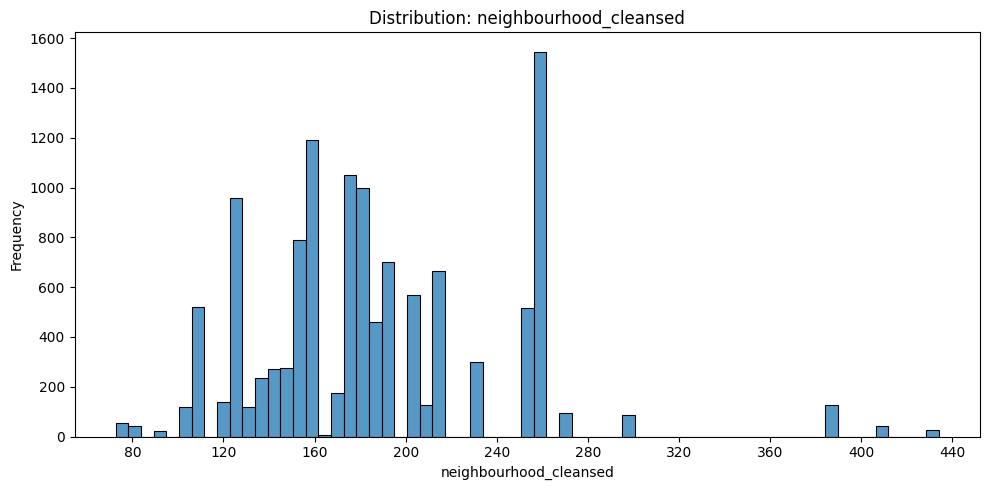

In [50]:
utl.plot_distributions(X_train, ['neighbourhood_cleansed'])

Our training and test sets are now fully numerical and could be used for training models.

In [51]:
print(X_train.info())
print(X_test.info())

<class 'pandas.core.frame.DataFrame'>
Index: 12220 entries, 7291 to 10209
Data columns (total 71 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   host_since                                        12220 non-null  float64
 1   host_response_time                                12220 non-null  float64
 2   host_response_rate                                12220 non-null  float64
 3   host_acceptance_rate                              12220 non-null  float64
 4   host_is_superhost                                 12220 non-null  float64
 5   host_listings_count                               12220 non-null  float64
 6   host_has_profile_pic                              12220 non-null  float64
 7   host_identity_verified                            12220 non-null  float64
 8   neighbourhood_cleansed                            12220 non-null  float64
 9   latitude           

### Distribution
We take a look at the distributions of some more features.

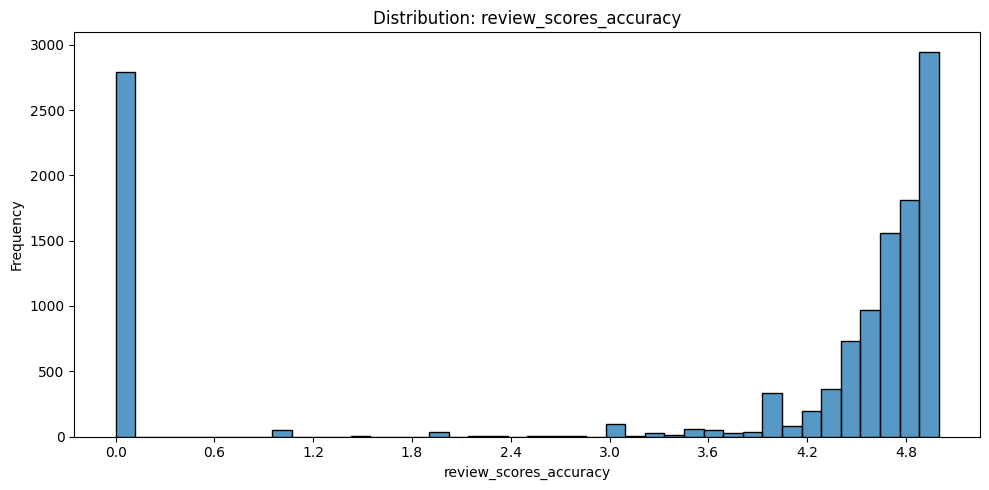

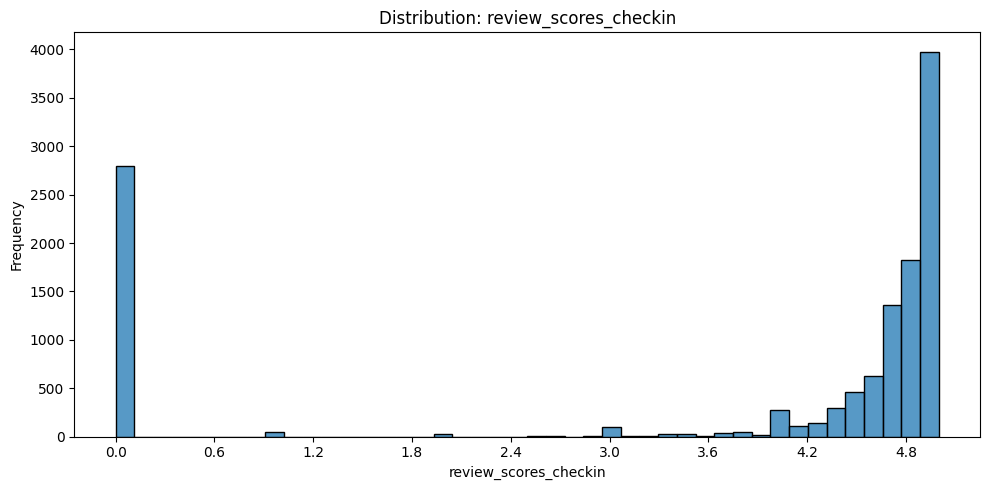

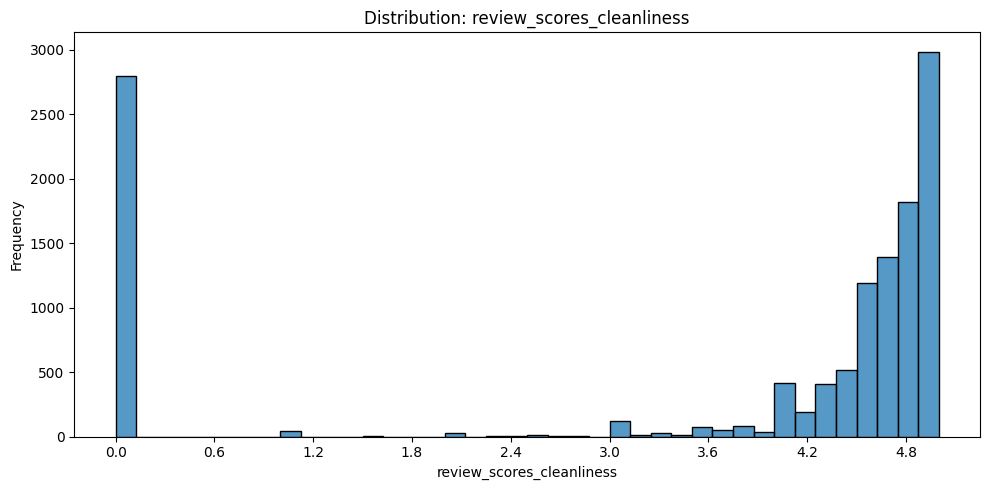

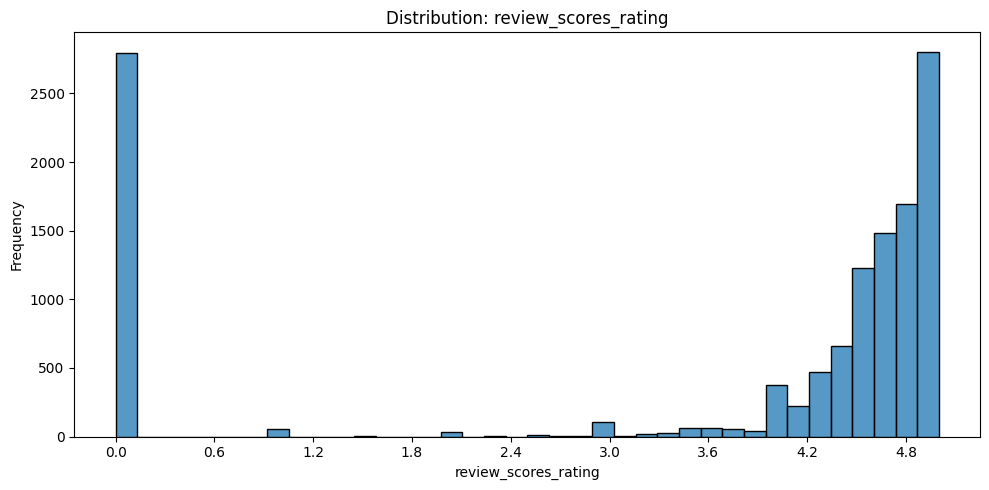

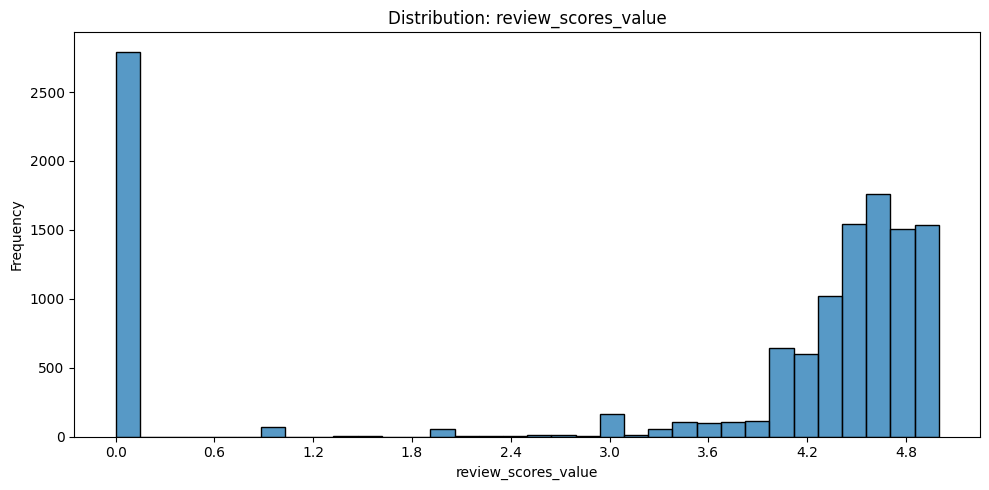

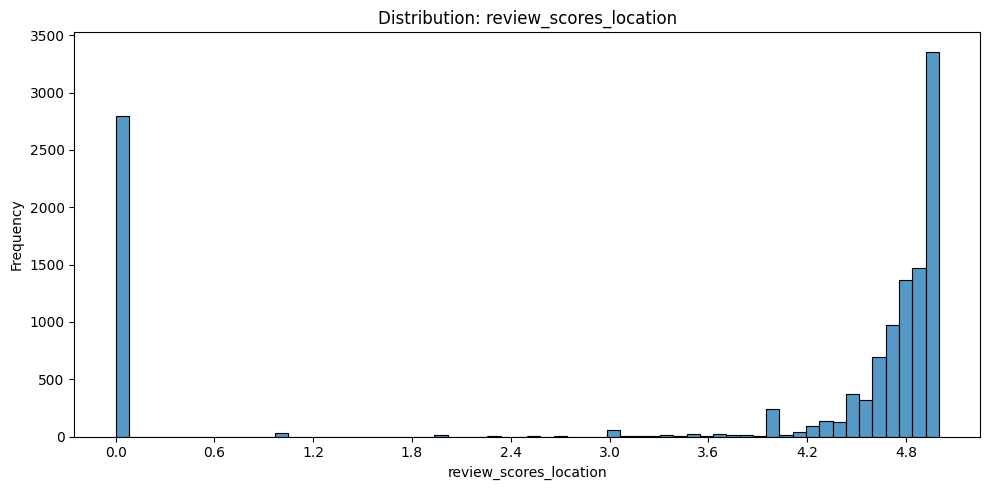

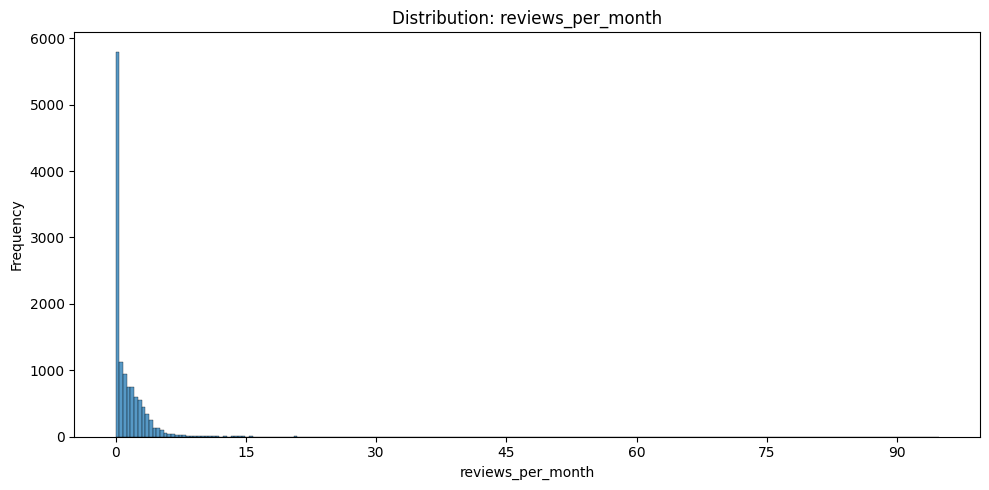

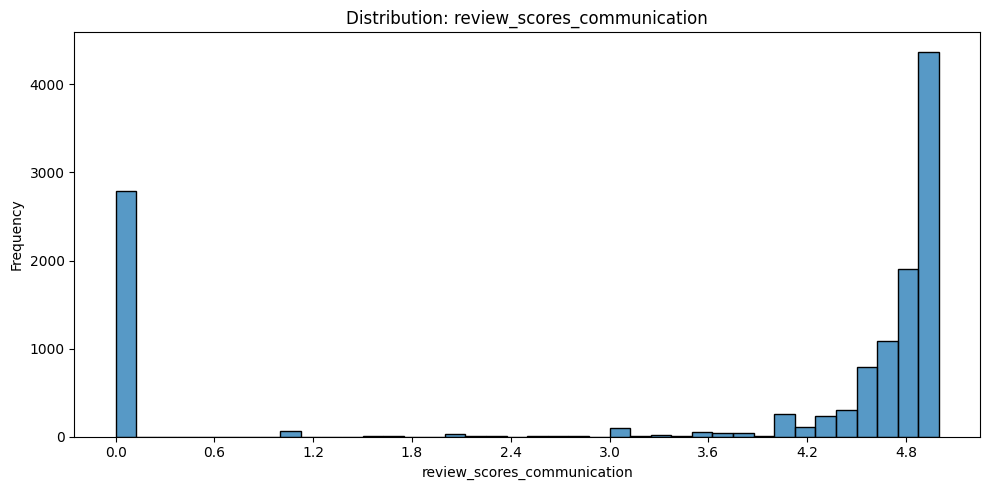

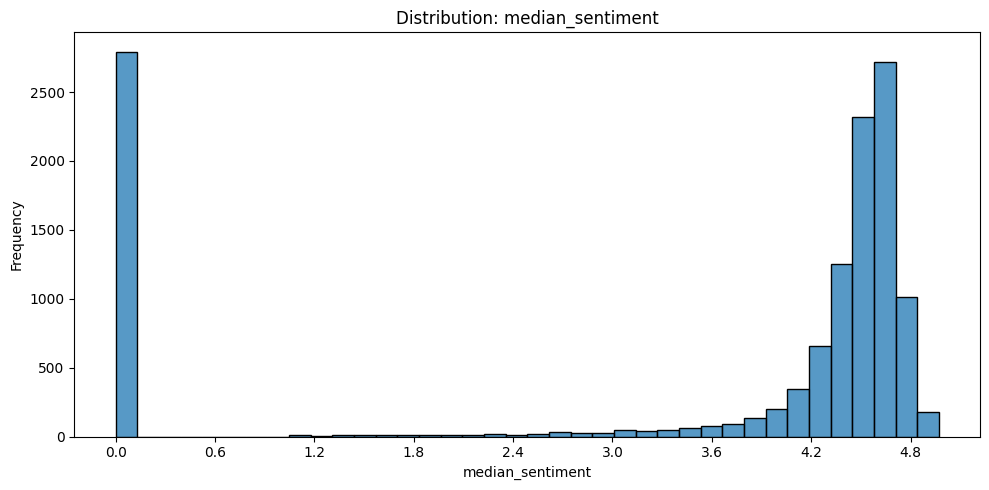

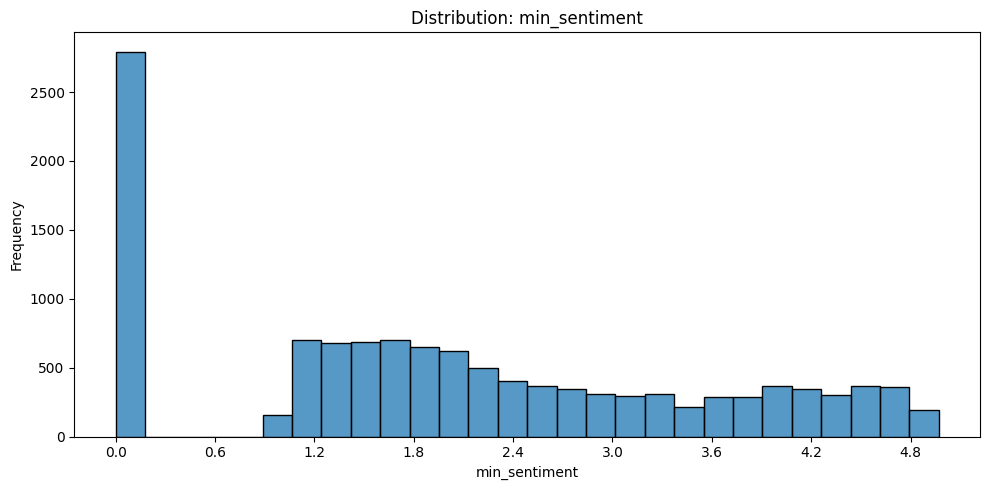

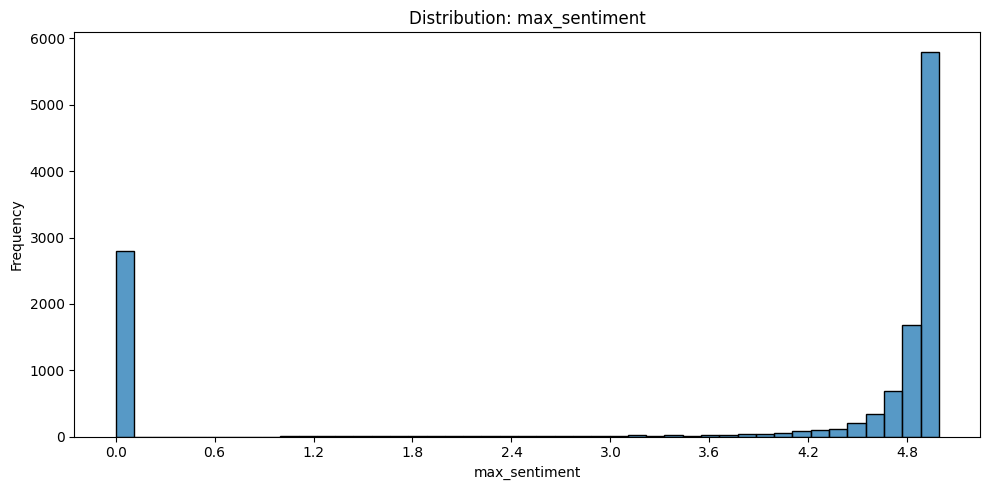

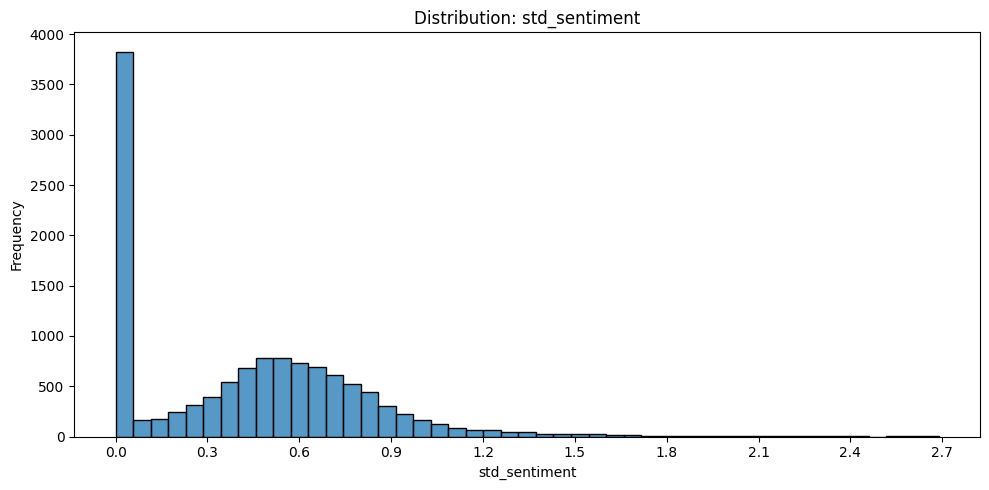

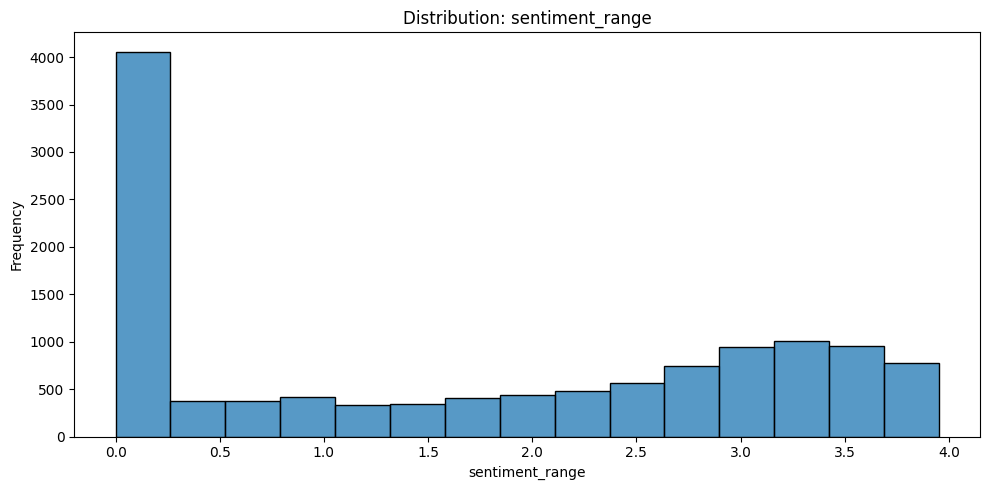

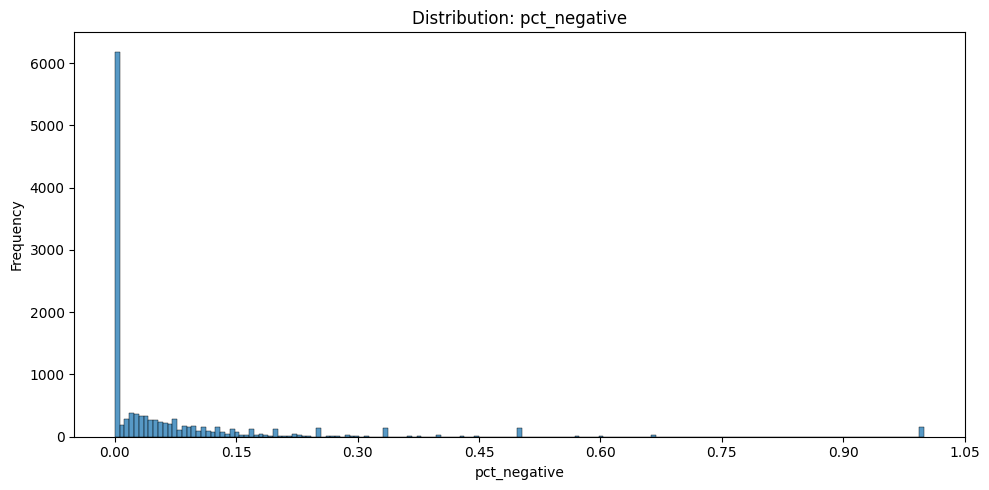

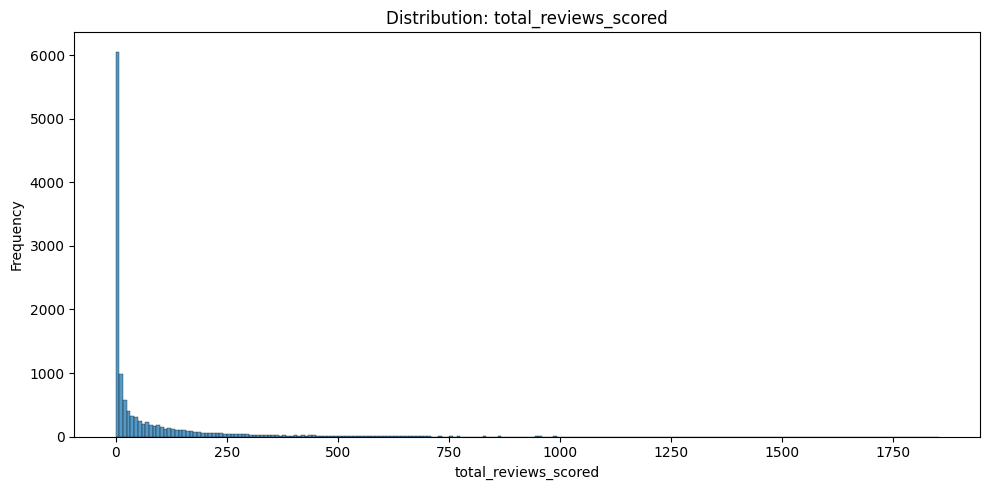

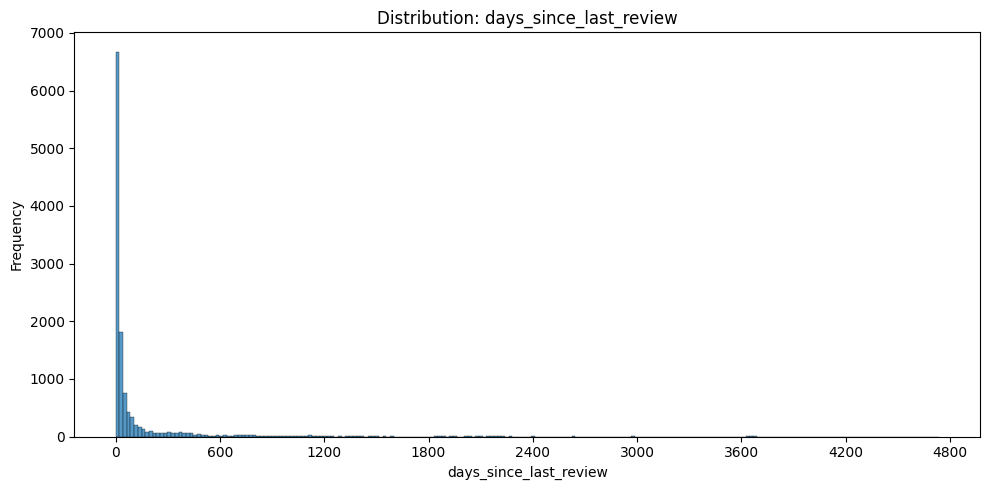

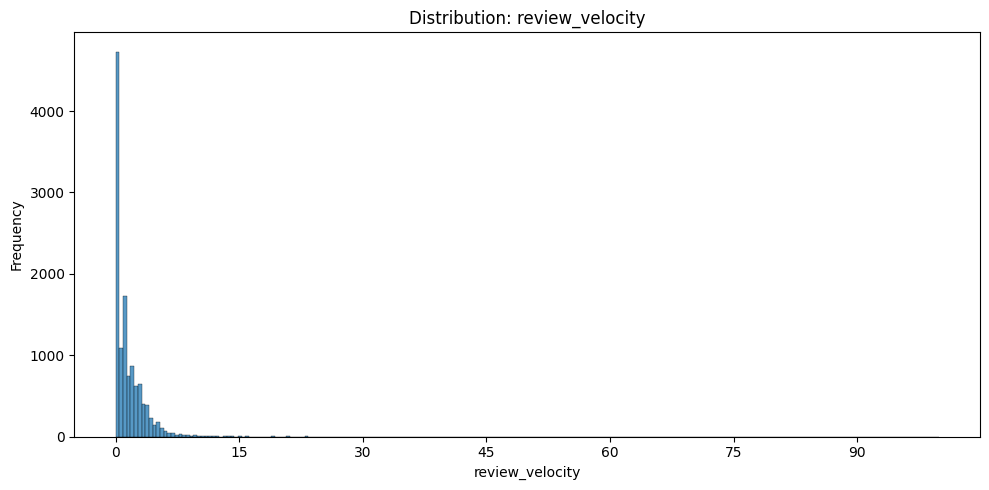

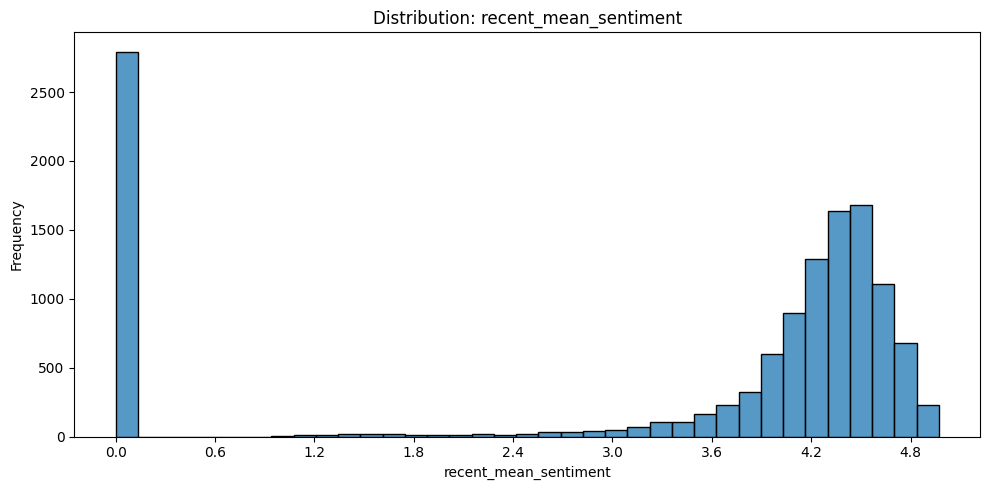

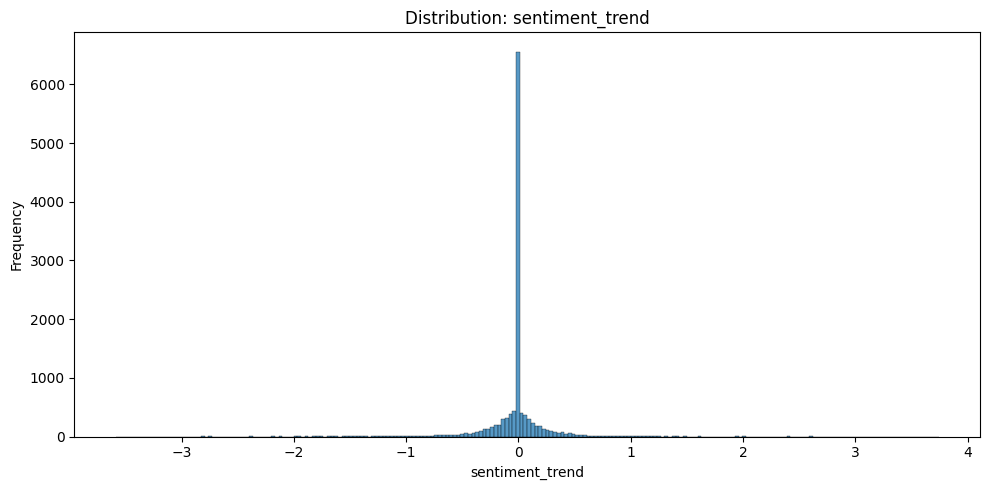

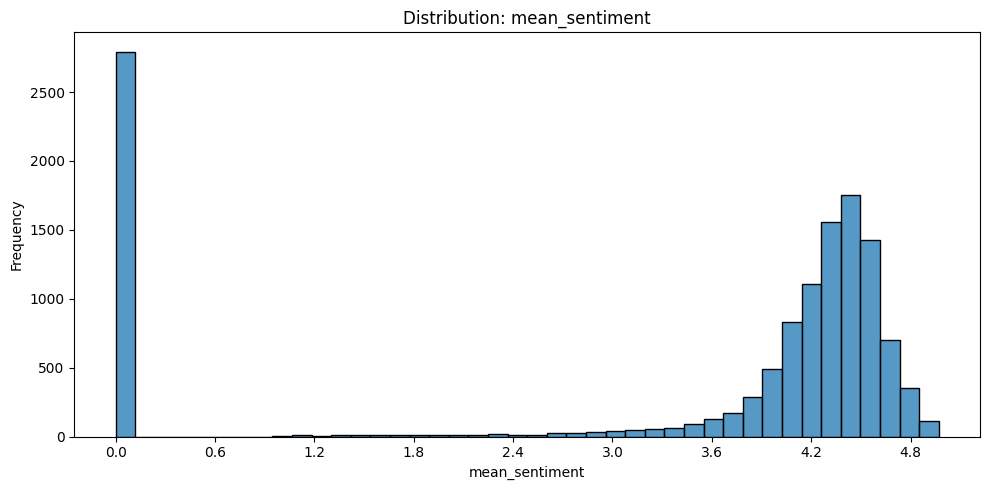

In [52]:
utl.plot_distributions(X_train, review_scores_features + sentiment_features)

## Feature Engineering

We calculate the distance to some famous landmarks in Barcelona.

In [53]:
# Create new features containing the distance of a listing to certain popular sights
X_train, X_test = dpp.distance_to_popular_landmarks(X_train, X_test)

We calculate the beds per accommodates for each listing.

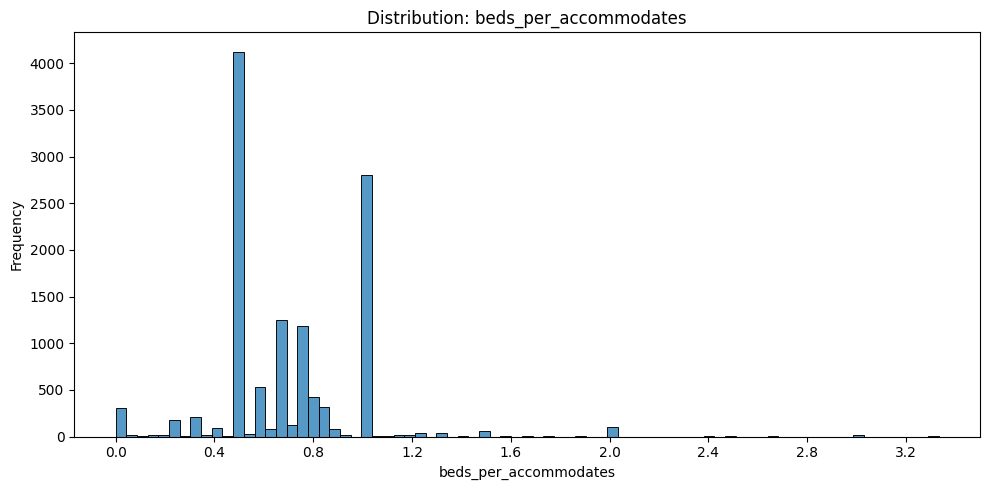

In [54]:
X_train, X_test = dpp.beds_per_accommodates(X_train, X_test)
utl.plot_distributions(X_train[['beds_per_accommodates']].loc[X_train['beds_per_accommodates'] < 4], ['beds_per_accommodates'])

We calculate the availability_ratio of each listing (availability_365 / 365).

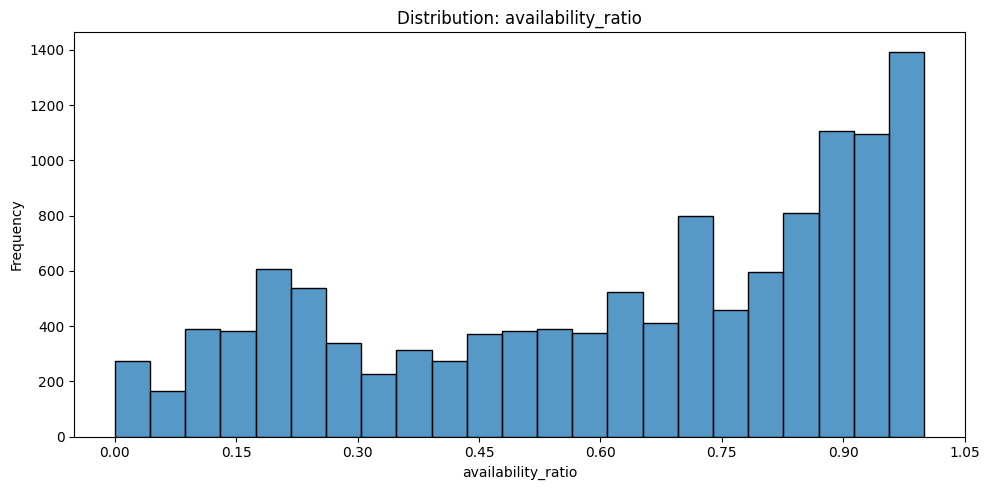

In [55]:
X_train, X_test = dpp.availability_ratio(X_train, X_test)
utl.plot_distributions(X_train, ['availability_ratio'])

### Log transformation
We log transform the target, because its distribution is skewed heavily.

In [56]:
# Take the log1p to avoid log(0)
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

In [408]:
errors = np.abs(trues_euro - preds_euro)
idx = np.argsort(errors)[-15:]    
for i in idx:
    print(f"true €{trues_euro[i]:.0f} | pred €{preds_euro[i]:.0f} | error €{errors[i]:.0f}")

true €1142 | pred €189 | error €953
true €1200 | pred €149 | error €1051
true €1995 | pred €719 | error €1276
true €2000 | pred €593 | error €1407
true €1804 | pred €195 | error €1609
true €3000 | pred €214 | error €2786
true €3000 | pred €207 | error €2793
true €3333 | pred €86 | error €3247
true €3608 | pred €211 | error €3397
true €3608 | pred €177 | error €3431
true €5000 | pred €357 | error €4643
true €9286 | pred €275 | error €9011
true €9500 | pred €223 | error €9277
true €10000 | pred €336 | error €9664
true €9999 | pred €92 | error €9907


In [412]:
for thr in [500, 750, 1000, 1500]:
    m = trues_euro < thr
    r2_t = r2_score(trues_euro[m], preds_euro[m])
    mae_t = mean_absolute_error(trues_euro[m], preds_euro[m])
    print(f"< €{thr}: keep {m.mean()*100:.1f}% | R²={r2_t:.3f} | MAE=€{mae_t:.2f}")

< €500: keep 96.8% | R²=0.593 | MAE=€41.72
< €750: keep 98.0% | R²=0.590 | MAE=€44.41
< €1000: keep 98.9% | R²=0.538 | MAE=€48.70
< €1500: keep 99.5% | R²=0.567 | MAE=€51.48


In [ ]:
amenity_cols = [col for col in mlb.classes_ if col in X_train.columns]

correlations = []
for col in amenity_cols:
    corr = X_train[col].corr(y_train_log)
    correlations.append(abs(corr))

corr_df = pd.DataFrame({'Amenity': amenity_cols, 'Correlation': correlations})
corr_df = corr_df.sort_values(by='Correlation', ascending=False).reset_index(drop=True)